In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error

In [ ]:
df = pd.read_csv('/content/Heart Disease Part3.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6183 entries, 0 to 6182
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       6183 non-null   int64  
 1   sex       6183 non-null   int64  
 2   cp        1943 non-null   float64
 3   trestbps  6183 non-null   float64
 4   chol      6133 non-null   float64
 5   fbs       6183 non-null   int64  
 6   restecg   1943 non-null   float64
 7   thalach   1943 non-null   float64
 8   exang     1943 non-null   float64
 9   oldpeak   1943 non-null   float64
 10  slope     1943 non-null   float64
 11  ca        1025 non-null   float64
 12  thal      1025 non-null   float64
 13  bmi       4221 non-null   float64
 14  glucose   3852 non-null   float64
 15  target    6183 non-null   int64  
dtypes: float64(12), int64(4)
memory usage: 773.0 KB


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,bmi,glucose,target
0,39,1,NaN,106.0,195.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.97,77.0,0
1,46,0,NaN,121.0,250.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.73,76.0,0
2,48,1,NaN,127.5,245.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.34,70.0,0
3,61,0,NaN,150.0,225.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.58,103.0,1
4,46,0,NaN,130.0,285.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.10,85.0,0


In [ ]:
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [ ]:
df_imputed

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,bmi,glucose,target
0,39.0,1.0,0.0,106.0,195.0,0.0,0.0,145.0,0.0,0.7,1.0,0.0,2.0,26.97,77.0,0.0
1,46.0,0.0,0.0,121.0,250.0,0.0,0.0,145.0,0.0,0.7,1.0,0.0,2.0,28.73,76.0,0.0
2,48.0,1.0,0.0,127.5,245.0,0.0,0.0,145.0,0.0,0.7,1.0,0.0,2.0,25.34,70.0,0.0
3,61.0,0.0,0.0,150.0,225.0,0.0,0.0,145.0,0.0,0.7,1.0,0.0,2.0,28.58,103.0,1.0
4,46.0,0.0,0.0,130.0,285.0,0.0,0.0,145.0,0.0,0.7,1.0,0.0,2.0,23.10,85.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6178,45.0,1.0,3.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,1.0,0.0,2.0,25.40,78.0,1.0
6179,68.0,1.0,0.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,1.0,0.0,2.0,25.40,78.0,1.0
6180,57.0,1.0,0.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,1.0,0.0,2.0,25.40,78.0,1.0
6181,57.0,0.0,1.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,1.0,0.0,2.0,25.40,78.0,1.0


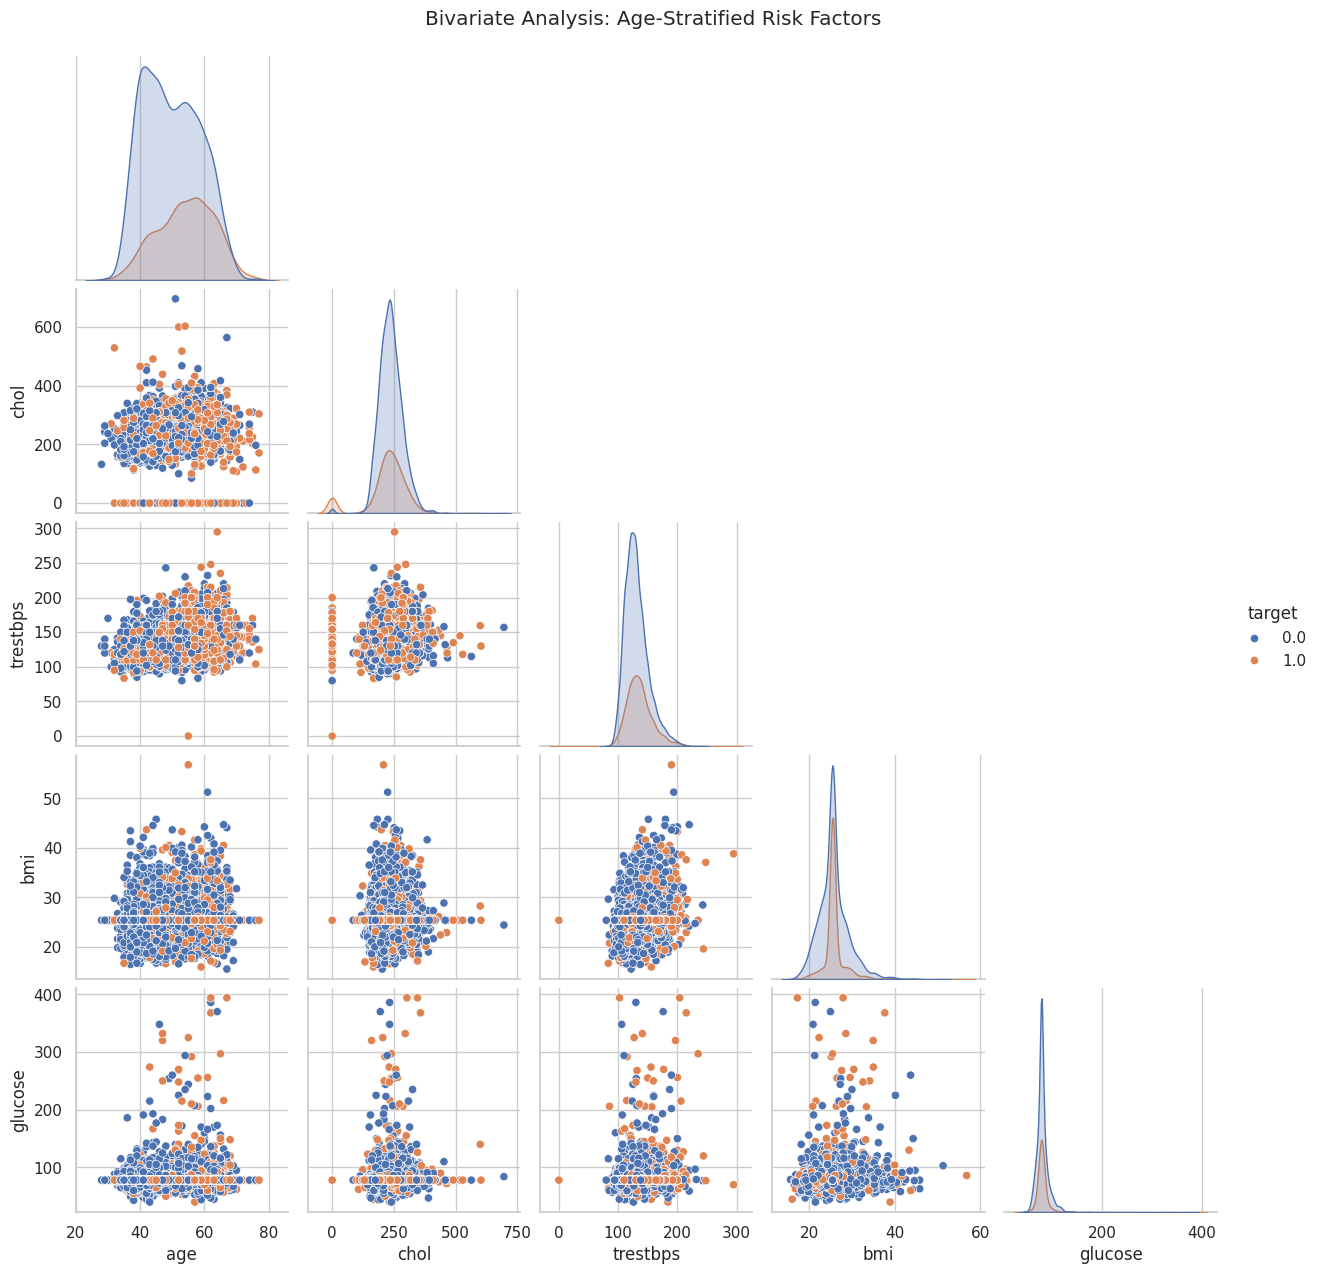

In [ ]:
sns.set(style="whitegrid")
analysis_cols = ['age', 'chol', 'trestbps', 'bmi', 'glucose', 'target']
sns.pairplot(df_imputed[analysis_cols], hue='target', diag_kind='kde', corner=True)
plt.suptitle("Bivariate Analysis: Age-Stratified Risk Factors", y=1.02)
plt.show()

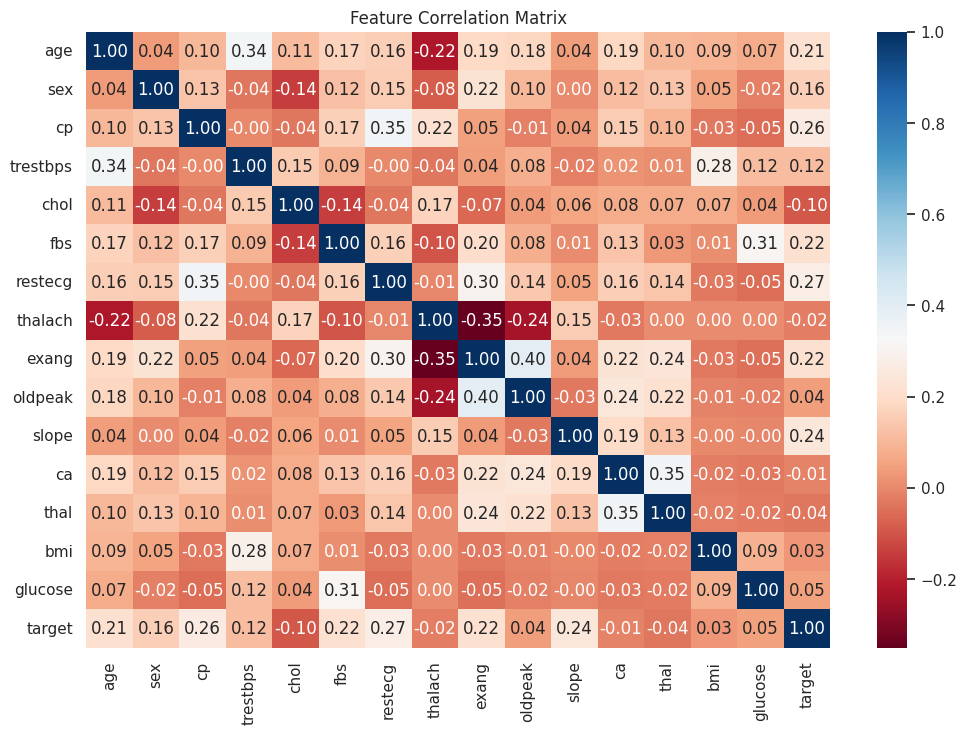

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_imputed.corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
X = df_imputed.drop('target', axis=1)
y= df_imputed['target']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test,y_train, y_test=train_test_split(X_scaled, y, test_size=0.2,random_state=42)

In [ ]:
models ={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN":KNeighborsClassifier(n_neighbors=5),
    "svm": SVC(probability=True,kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}


In [ ]:
error_metrics = {}

for name, model in models.items():

    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]


    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    error_metrics[name] = {
        "MSE": mse,
        "RMSE": rmse
    }


--- Logistic Regression ---
              precision    recall  f1-score   support

         0.0       0.80      0.93      0.86       889
         1.0       0.71      0.41      0.52       348

    accuracy                           0.79      1237
   macro avg       0.75      0.67      0.69      1237
weighted avg       0.78      0.79      0.77      1237

ROC-AUC Score: 0.7988

--- KNN ---
              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88       889
         1.0       0.74      0.54      0.62       348

    accuracy                           0.82      1237
   macro avg       0.79      0.73      0.75      1237
weighted avg       0.81      0.82      0.81      1237

ROC-AUC Score: 0.8050

--- svm ---
              precision    recall  f1-score   support

         0.0       0.83      0.97      0.90       889
         1.0       0.88      0.50      0.64       348

    accuracy                           0.84      1237
   macro avg       0.85      

In [ ]:
error_df = pd.DataFrame(error_metrics).T
print("\nError Metrics for All Models:")
print(error_df)


Error Metrics for All Models:
                          MSE      RMSE
Logistic Regression  0.213420  0.461974
KNN                  0.182700  0.427434
svm                  0.160065  0.400081
Random Forest        0.148747  0.385677


In [ ]:
import pickle

with open("heart_disease 2026 part 3.pkl","wb")as f:
  pickle.dump(models,f)
  print("Model Saved Successfully")

Model Saved Successfully
